In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np

In [11]:
# Load the data
try:
    data = pd.read_csv('./mushrooms.csv')
except FileNotFoundError:
    print("Error: mushrooms.csv not found. Make sure the file is in the same directory or provide the correct path.")
    exit()

In [13]:
# Convert categorical features to dummy variables
X = pd.get_dummies(data.drop("class", axis=1))
y = data["class"]

In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# --- Part 1: Training and Evaluating with all features ---

# Train a decision tree classifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = dtree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy with all features: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy with all features: 1.0
Confusion Matrix:
[[843   0]
 [  0 782]]


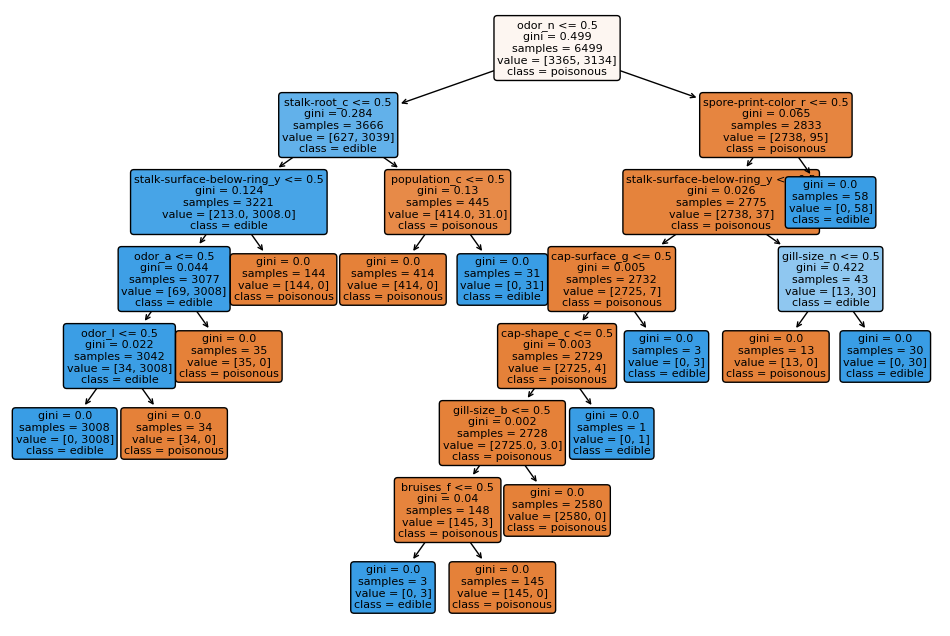

In [19]:
# Visualize the decision tree (optional, might be large)
plt.figure(figsize=(12, 8))
plot_tree(dtree, feature_names=X.columns, class_names=["poisonous", "edible"], filled=True, rounded=True, fontsize=8)
plt.show()

In [21]:
# --- Part 2: Feature Selection and Evaluation ---

# Select top 5 features using chi-squared statistic
selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X, y)

In [23]:
# Get the indices of the selected features
selected_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_features = list(X.columns[selected_indices])
print("Selected features:", selected_features)

Selected features: ['odor_f', 'odor_n', 'gill-color_b', 'stalk-surface-above-ring_k', 'stalk-surface-below-ring_k']


In [25]:
# Split the selected features into training and testing sets
X_train_selected, X_test_selected, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Retrain the decision tree with the selected features
dtree_selected = DecisionTreeClassifier(random_state=42)
dtree_selected.fit(X_train_selected, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
# Make predictions and evaluate
y_pred_selected = dtree_selected.predict(X_test_selected)
accuracy_selected = accuracy_score(y_test, y_pred_selected)
conf_matrix_selected = confusion_matrix(y_test, y_pred_selected)

print(f"Accuracy with selected features: {accuracy_selected}")
print("Confusion Matrix:")
print(conf_matrix_selected)


Accuracy with selected features: 0.9267692307692308
Confusion Matrix:
[[843   0]
 [119 663]]


## Summarize findings

In [32]:
print("\nSummary:")
print("Using all features, the decision tree achieved high accuracy. However, feature selection revealed a smaller subset of features that still yielded comparable accuracy, suggesting those features are particularly informative for classification.")


Summary:
Using all features, the decision tree achieved high accuracy. However, feature selection revealed a smaller subset of features that still yielded comparable accuracy, suggesting those features are particularly informative for classification.
